In [1]:
# import library yang dibutuhkan

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
# membaca dataset

df = pd.read_csv('databansk.csv', sep=';')
df.head()

,Ban,Harga,Terjual
0,Maxxis M 6167 H 70/90 - 14,165,78
1,Maxxis M 6167 H 80/90 - 14,185,75
2,Maxxis M 6167 H 90/90 - 14,230,70
3,Maxxis M 6212 H 80/90 - 14,185,76
4,Maxxis M 6239 H 80/90 - 14,200,73


In [3]:
# persiapan dataset

X = df.drop(['Ban'], axis=1)
print(X)

    Harga  Terjual
0     165       78
1     185       75
2     230       70
3     185       76
4     200       73
..    ...      ...
90    320       61
91    385       55
92    400       54
93    300       63
94    360       58

[95 rows x 2 columns]


Text(4, 600000, 'Possible Elbow Point')

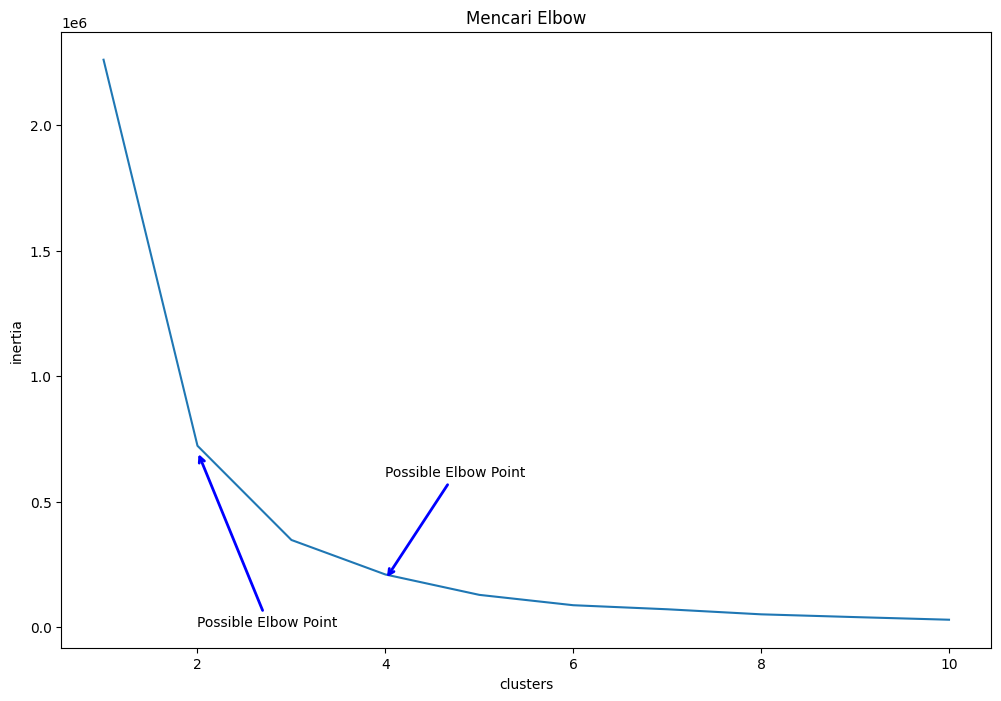

In [4]:
# menentukan jumlah cluster dengan elbow

clusters=[]
for i in range(1,11):
    km = KMeans(n_clusters=i).fit(X)
    clusters.append(km.inertia_)

fig, ax = plt.subplots(figsize=(12,8))
sns.lineplot(x=list(range(1,11)), y=clusters, ax=ax)
ax.set_title('Mencari Elbow')
ax.set_xlabel('clusters')
ax.set_ylabel('inertia')

# panah elbow

ax.annotate('Possible Elbow Point', xy=(2, 700000), xytext=(2, 2000), xycoords='data', 
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='blue', lw=2))

ax.annotate('Possible Elbow Point', xy=(4, 190000), xytext=(4, 600000), xycoords='data', 
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='blue', lw=2))


In [5]:
# proses clustering

n_clust = 3
kmean = KMeans(n_clusters=n_clust).fit(X)
X['Labels'] = kmean.labels_

# Urutkan cluster berdasarkan rata-rata Terjual (tertinggi → terendah)
cluster_mean = X.groupby('Labels')['Terjual'].mean().sort_values(ascending=False)

# Mapping ulang ke label 1, 2, 3
label_mapping = {old_label: new_label + 1 
                 for new_label, old_label in enumerate(cluster_mean.index)}

# Simpan label yang sudah stabil
X['Labels_Fix'] = X['Labels'].map(label_mapping)

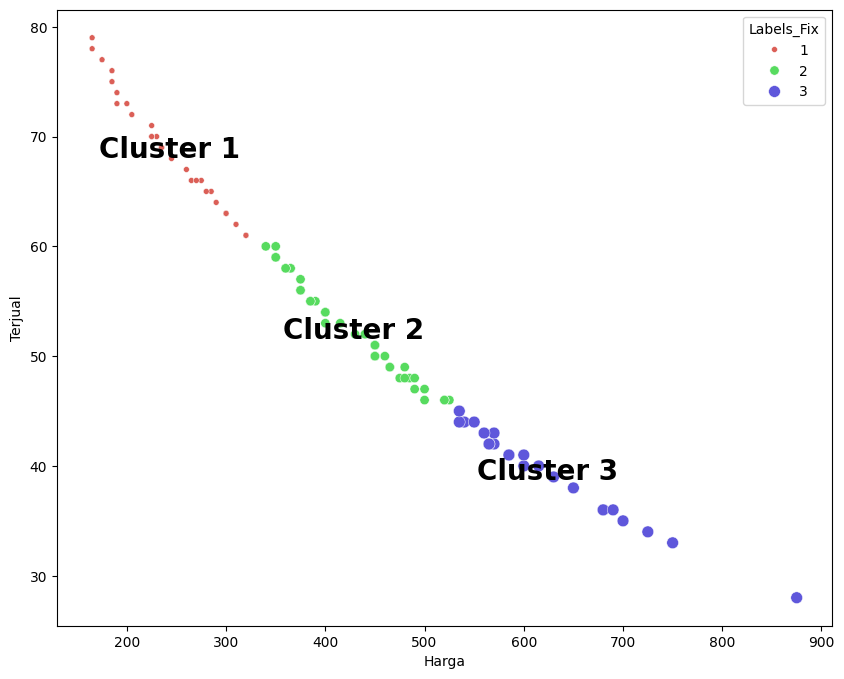

In [6]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=X,
    x='Harga',
    y='Terjual',
    hue='Labels_Fix',
    size='Labels_Fix',
    palette=sns.color_palette('hls', n_clust)
)

for label in sorted(X['Labels_Fix'].unique()):
    plt.annotate(
        f'Cluster {label}',
        (
            X[X['Labels_Fix'] == label]['Harga'].mean(),
            X[X['Labels_Fix'] == label]['Terjual'].mean()
        ),
        horizontalalignment='center',
        verticalalignment='center',
        size=20,
        weight='bold',
        color='black'
    )

plt.show()

In [7]:
print(X)

    Harga  Terjual  Labels  Labels_Fix
0     165       78       1           1
1     185       75       1           1
2     230       70       1           1
3     185       76       1           1
4     200       73       1           1
..    ...      ...     ...         ...
90    320       61       1           1
91    385       55       2           2
92    400       54       2           2
93    300       63       1           1
94    360       58       2           2

[95 rows x 4 columns]


In [8]:
X.to_excel("output_cluster_ban.xlsx")